In [1]:
import pandas as pd
import plotly.graph_objects as go

In [2]:
# Cargar datos de matrícula escolar
matriculas = pd.read_csv('../fuentes/matricula_escolar_por_entidad_federativa_por_grado.csv')
matriculas

,Entidad federativa,Nivel educativo,Total,Hombres,Mujeres
0,Estados Unidos Mexicanos,Total,"32,614,956","16,430,576","16,184,380"
1,Estados Unidos Mexicanos,Inicial,"229,778","119,743","110,035"
2,Estados Unidos Mexicanos,Preescolar,"3,996,767","2,003,739","1,993,028"
3,Estados Unidos Mexicanos,Primaria,"12,838,059","6,501,947","6,336,112"
4,Estados Unidos Mexicanos,Secundaria,"6,293,530","3,164,785","3,128,745"
...,...,...,...,...,...
226,Zacatecas,Preescolar,"64,288","32,427","31,861"
227,Zacatecas,Primaria,"185,456","93,875","91,581"
228,Zacatecas,Secundaria,"88,302","44,217","44,085"
229,Zacatecas,Media superior,"64,049","29,640","34,409"


In [3]:
# Función para convertir números con comas a enteros
def limpiar_numero(valor):
    if isinstance(valor, str):
        return int(valor.replace(',', ''))
    return valor

# Limpiar columnas numéricas
for col in ['Total', 'Hombres', 'Mujeres']:
    matriculas[col] = matriculas[col].apply(limpiar_numero)

# Filtrar solo datos nacionales (Estados Unidos Mexicanos)
nacional = matriculas[matriculas['Entidad federativa'] == 'Estados Unidos Mexicanos'].copy()

# Seleccionar solo niveles de primaria a superior (excluir Total, Inicial, Preescolar)
niveles_orden = ['Primaria', 'Secundaria', 'Media superior', 'Superior']
nacional = nacional[nacional['Nivel educativo'].isin(niveles_orden)]

# Ordenar según el orden educativo
nacional['orden'] = nacional['Nivel educativo'].map({n: i for i, n in enumerate(niveles_orden)})
nacional = nacional.sort_values('orden')

nacional

,Entidad federativa,Nivel educativo,Total,Hombres,Mujeres,orden
3,Estados Unidos Mexicanos,Primaria,12838059,6501947,6336112,0
4,Estados Unidos Mexicanos,Secundaria,6293530,3164785,3128745,1
5,Estados Unidos Mexicanos,Media superior,5097942,2459900,2638042,2
6,Estados Unidos Mexicanos,Superior,4158880,1934266,2224614,3


In [4]:
# Calcular porcentajes del total respecto a primaria (base = 100)
total_primaria = nacional['Total'].iloc[0]
nacional['porcentaje'] = [round((t / total_primaria) * 100) for t in nacional['Total']]

nacional[['Nivel educativo', 'Total', 'porcentaje']]

,Nivel educativo,Total,porcentaje
3,Primaria,12838059,100
4,Secundaria,6293530,49
5,Media superior,5097942,40
6,Superior,4158880,32


In [5]:
# Datos para el embudo
stages = ['Primaria', 'Secundaria', 'Media Superior', 'Superior']
valores = nacional['porcentaje'].values.tolist()

# Obtener los valores totales para mostrar en millones
totales = nacional['Total'].values.tolist()
# Crear etiquetas con millones (negrita) y porcentaje debajo
text_labels = [f"<b>{t/1_000_000:.1f}M</b><br>{p}%" for t, p in zip(totales, valores)]

# Generar gradiente de colores de #114038 a #8ee3d5
# Color inicial: #114038 (RGB: 17, 64, 56)
# Color final: #8ee3d5 (RGB: 142, 227, 213)

def interpolate_color(color1, color2, factor):
    """Interpolar entre dos colores hex"""
    r1, g1, b1 = int(color1[1:3], 16), int(color1[3:5], 16), int(color1[5:7], 16)
    r2, g2, b2 = int(color2[1:3], 16), int(color2[3:5], 16), int(color2[5:7], 16)
    
    r = int(r1 + (r2 - r1) * factor)
    g = int(g1 + (g2 - g1) * factor)
    b = int(b1 + (b2 - b1) * factor)
    
    return f"#{r:02x}{g:02x}{b:02x}"

color_start = "#114038"
color_end = "#8ee3d5"
n_levels = len(stages)

# Generar colores para cada nivel
colors = [interpolate_color(color_start, color_end, i / (n_levels - 1)) for i in range(n_levels)]

print("Colores del gradiente:")
for stage, color, val in zip(stages, colors, valores):
    print(f"  {stage}: {color} -> {val}%")

Colores del gradiente:
  Primaria: #114038 -> 100%
  Secundaria: #3a766c -> 49%
  Media Superior: #64aca0 -> 40%
  Superior: #8ee3d5 -> 32%


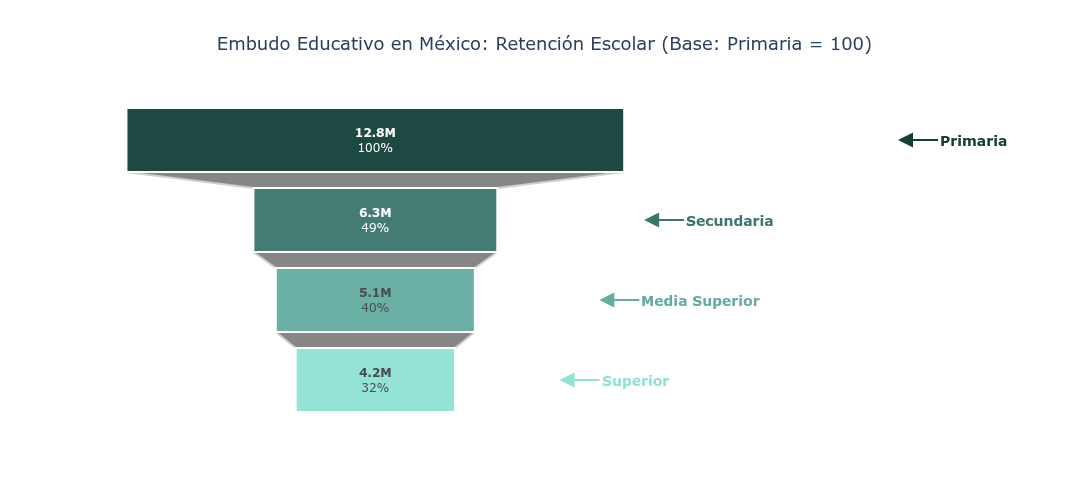

In [6]:
# Crear el embudo con plotly.graph_objects para tener control total de colores
fig = go.Figure(go.Funnel(
    y=stages,
    x=valores,
    text=text_labels,
    textposition="inside",
    textinfo="text",
    marker=dict(
        color=colors,
        line=dict(color="white", width=2)
    ),
    connector=dict(line=dict(color="#cccccc", width=2)),
    opacity=0.95
))

# Crear anotaciones con flechas que apuntan a cada nivel del embudo
annotations = []
for i, (stage, color, val) in enumerate(zip(stages, colors, valores)):
    annotations.append(dict(
        x=val + 5,
        y=stage,
        xref='x',
        yref='y',
        text=f"<b>{stage}</b>",
        showarrow=True,
        arrowhead=2,
        arrowsize=1.5,
        arrowwidth=2,
        arrowcolor=color,
        font=dict(color=color, size=14),
        ax=40,
        ay=0,
        align='left',
        xanchor='left'
    ))

# Actualizar el diseño
fig.update_layout(
    title={
        'text': 'Embudo Educativo en México: Retención Escolar (Base: Primaria = 100)',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18}
    },
    height=500,
    width=900,
    showlegend=False,
    paper_bgcolor="white",
    plot_bgcolor="white",
    annotations=annotations,
    yaxis=dict(showticklabels=False)
)

# Actualizar ejes
fig.update_xaxes(title_text="% respecto a Primaria")

fig.show()

In [7]:
# Crear tabla resumen con los colores
resumen = pd.DataFrame({
    'Nivel Educativo': stages,
    'Matrícula Total': nacional['Total'].values,
    '% respecto a Primaria': [f"{p}%" for p in valores],
    'Color': colors
})

print("Tabla de Retención Educativa en México")
print("="*70)
print(resumen.to_string(index=False))

print("\n\nInterpretación:")
print("- Primaria = 100% (cohorte base)")
print("- Los siguientes niveles muestran el % de estudiantes que se retienen")
print("- respecto al total de matriculados en primaria")
print("- El gradiente va de verde oscuro (#114038) a verde claro (#8ee3d5)")

Tabla de Retención Educativa en México
Nivel Educativo  Matrícula Total % respecto a Primaria   Color
       Primaria         12838059                  100% #114038
     Secundaria          6293530                   49% #3a766c
 Media Superior          5097942                   40% #64aca0
       Superior          4158880                   32% #8ee3d5


Interpretación:
- Primaria = 100% (cohorte base)
- Los siguientes niveles muestran el % de estudiantes que se retienen
- respecto al total de matriculados en primaria
- El gradiente va de verde oscuro (#114038) a verde claro (#8ee3d5)
